In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2

data visualization

In [3]:
Stock_data = yf.download('MSFT', start='2015-01-01', end='2026-01-01')

Stock_data.columns = Stock_data.columns.get_level_values(0)
Stock_data['MA10'] = Stock_data['Close'].rolling(10).mean()
Stock_data['EMA20'] = Stock_data['Close'].ewm(span=20).mean()
Stock_data['Return'] = Stock_data['Close'].pct_change()
Stock_data['Volatility'] = Stock_data['Return'].rolling(10).std()


Stock_data.head()

/tmp/ipykernel_1447/3637979465.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Stock_data = yf.download('MSFT', start='2015-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,MA10,EMA20,Return,Volatility
Date,,,,,,,,,
2015-01-02,39.767677,40.328983,39.580578,39.682632,27913900,NaN,39.767677,NaN,NaN
2015-01-05,39.401985,39.742169,39.333947,39.436001,39673900,NaN,39.575689,-0.009196,NaN
2015-01-06,38.823677,39.759186,38.730126,39.444515,36447900,NaN,39.299555,-0.014677,NaN
2015-01-07,39.316940,39.512547,38.687599,39.104324,29114100,NaN,39.304574,0.012705,NaN
2015-01-08,40.473572,40.609646,39.733669,39.759182,29645200,NaN,39.587344,0.029418,NaN


In [4]:
Stock_data.tail()

Price,Close,High,Low,Open,Volume,MA10,EMA20,Return,Volatility
Date,,,,,,,,,
2025-12-24,486.908630,488.046049,483.725892,484.573963,5855900,480.804590,484.251528,0.002403,0.007860
2025-12-26,486.599365,487.008435,484.853350,485.601642,8842200,481.227625,484.475132,-0.000635,0.007322
2025-12-29,485.990753,487.237907,483.077389,483.755834,10893400,482.082672,484.619477,-0.001251,0.006286
2025-12-30,486.369904,488.564875,484.394402,484.823415,13944500,483.345792,484.786184,0.000780,0.005356
2025-12-31,482.518677,487.028403,482.199398,486.729068,15601600,484.067145,484.570231,-0.007918,0.006296


In [5]:
Stock_data .info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Close       2766 non-null   float64
 1   High        2766 non-null   float64
 2   Low         2766 non-null   float64
 3   Open        2766 non-null   float64
 4   Volume      2766 non-null   int64  
 5   MA10        2757 non-null   float64
 6   EMA20       2766 non-null   float64
 7   Return      2765 non-null   float64
 8   Volatility  2756 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 216.1 KB


In [6]:
Stock_data.describe()

Price,Close,High,Low,Open,Volume,MA10,EMA20,Return,Volatility
count,2766.000000,2766.000000,2766.000000,2766.000000,2.766000e+03,2757.000000,2766.000000,2765.000000,2756.000000
mean,205.707176,207.568928,203.661644,205.662655,2.827508e+07,205.522065,204.177313,0.001046,0.014916
std,142.969654,144.139209,141.710443,142.987318,1.314165e+07,142.523200,142.142048,0.016938,0.008644
min,34.358742,34.894493,34.214157,34.520325,5.855900e+06,35.183113,35.660020,-0.147390,0.002355
25%,68.635908,68.939475,68.046973,68.601667,2.008620e+07,68.507618,67.765252,-0.006727,0.009415
50%,191.641525,193.939605,187.826472,190.869104,2.505275e+07,194.244434,185.558424,0.000955,0.012888
75%,311.784264,314.644818,308.703774,311.866473,3.268428e+07,313.498767,311.646884,0.009428,0.018168
max,539.825256,552.242002,538.530652,552.023241,1.691640e+08,523.633557,520.709587,0.142169,0.089051


In [7]:
Stock_data.isnull().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0
MA10,9
EMA20,0
Return,1
Volatility,10


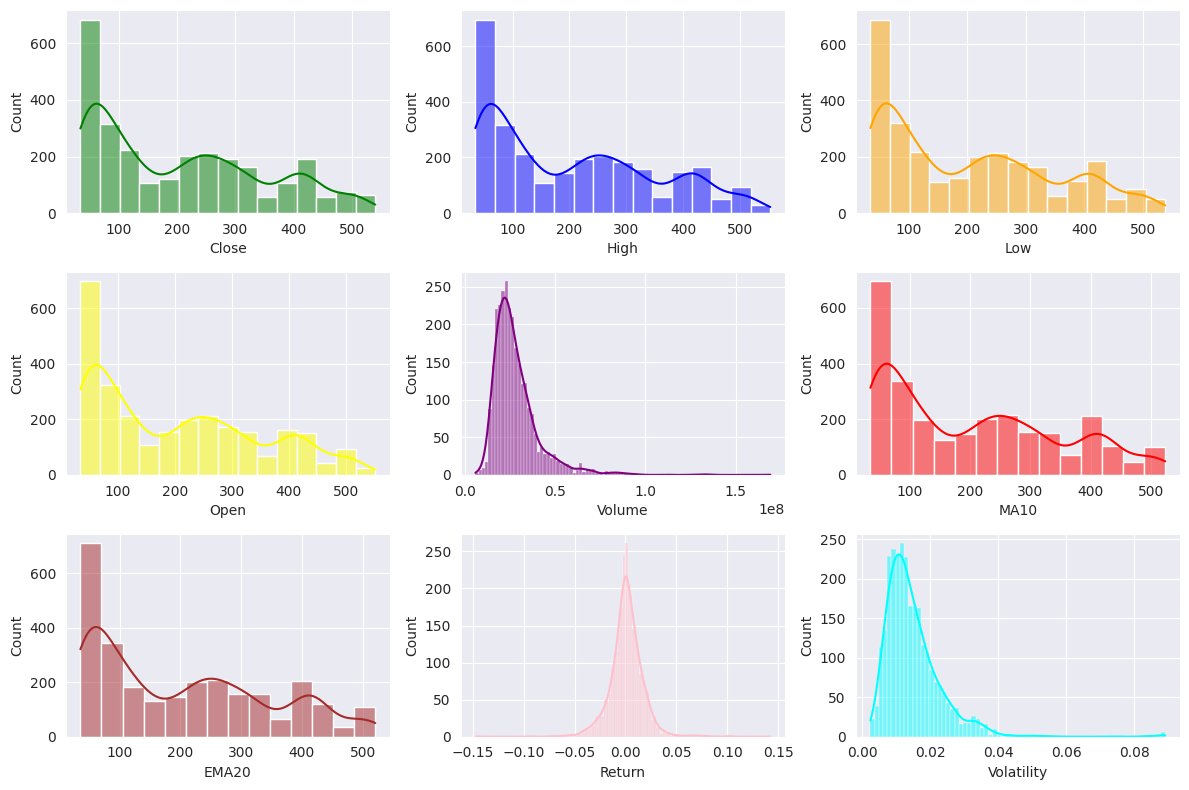

In [8]:
sns.set_style("darkgrid")

fig, ax = plt.subplots(3,3, figsize=(12,8))

sns.histplot(data=Stock_data, x='Close', kde=True, ax=ax[0,0], color='green')
sns.histplot(data=Stock_data, x='High', kde=True, ax=ax[0,1], color='blue')
sns.histplot(data=Stock_data, x='Low', kde=True, ax=ax[0,2], color='orange')
sns.histplot(data=Stock_data, x='Open', kde=True, ax=ax[1,0], color= 'yellow')
sns.histplot(data=Stock_data, x='Volume', kde=True, ax=ax[1,1], color= 'purple')
sns.histplot(data=Stock_data, x='MA10', kde=True, ax=ax[1,2], color= 'red')
sns.histplot(data=Stock_data, x='EMA20', kde=True, ax=ax[2,0], color= 'brown')
sns.histplot(data=Stock_data, x='Return', kde=True, ax=ax[2,1], color= 'pink')
sns.histplot(data=Stock_data, x='Volatility', kde=True, ax=ax[2,2], color= 'cyan')

plt.tight_layout()
plt.show()

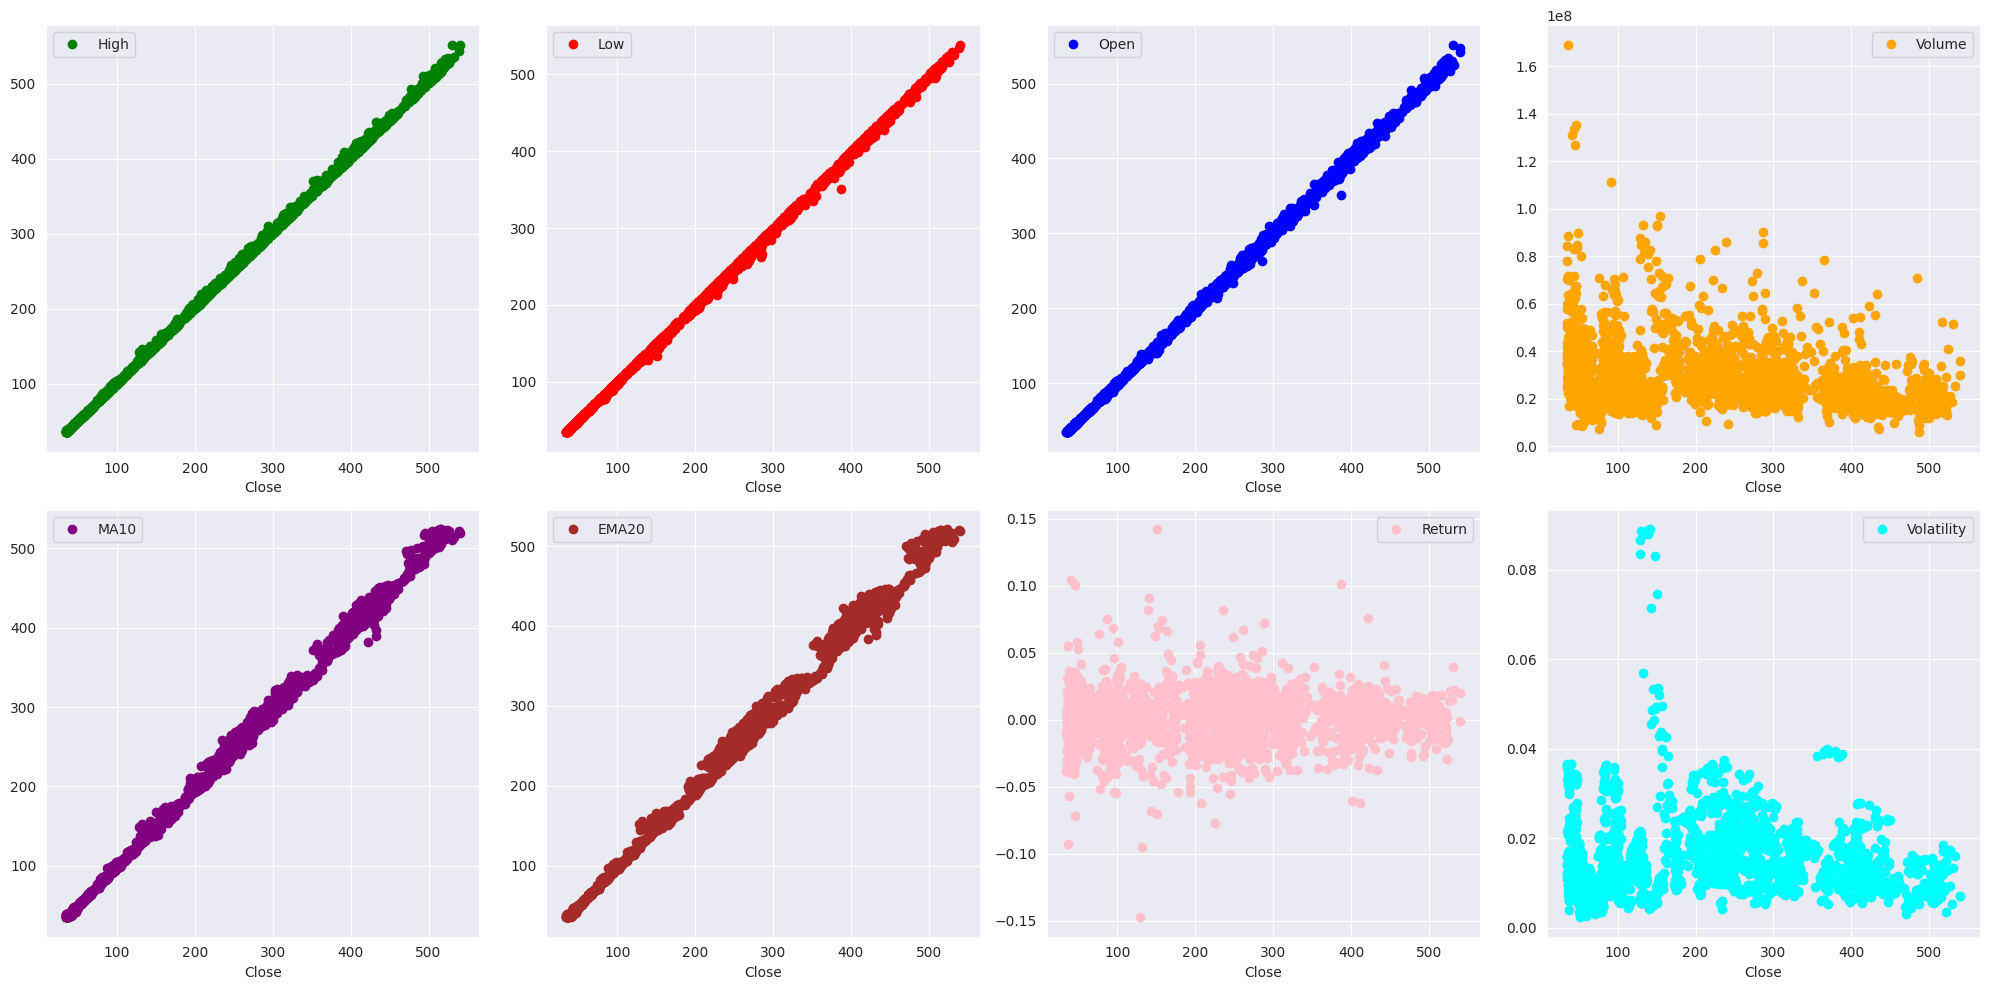

In [9]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10)) # Increased subplot grid to 2 rows and 4 columns


Stock_data.plot(x='Close', y='High', style='o', ax=axs[0,0], color='green')
Stock_data.plot(x='Close', y='Low', style='o', ax=axs[0,1], color='red')
Stock_data.plot(x='Close', y='Open', style='o', ax=axs[0,2], color='blue')
Stock_data.plot(x='Close', y='Volume', style='o', ax=axs[0,3], color='orange')
Stock_data.plot(x='Close', y='MA10', style='o', ax=axs[1,0], color='purple')
Stock_data.plot(x='Close', y='EMA20', style='o', ax=axs[1,1], color='brown')
Stock_data.plot(x='Close', y='Return', style='o', ax=axs[1,2], color='pink')
Stock_data.plot(x='Close', y='Volatility', style='o', ax=axs[1,3], color='cyan')

plt.tight_layout()
plt.show()

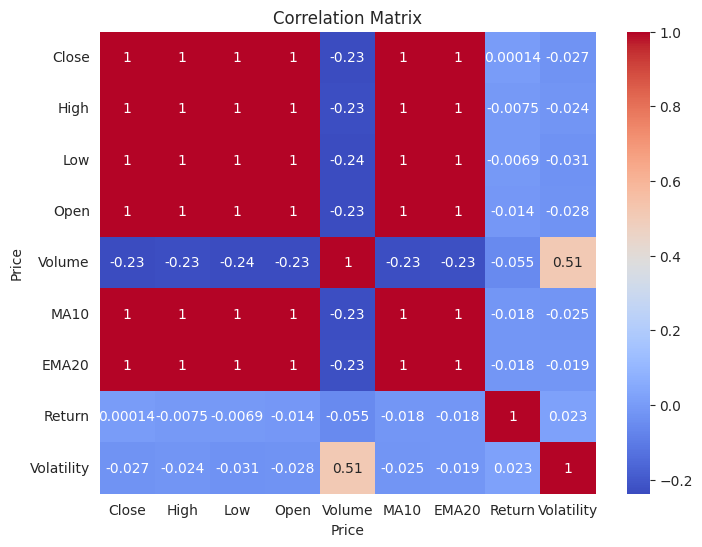

In [ ]:
plt.figure(figsize=(8,6))

corr = Stock_data.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

data preprocessing

In [10]:
Stock_data.dropna(inplace=True)


features = ['Close', 'MA10', 'EMA20', 'Volatility']
data = Stock_data[features]

dataset = data.values

# Close price
close_price_scaler = MinMaxScaler(feature_range=(0,1))
scaled_close_price = close_price_scaler.fit_transform(dataset[:, 0].reshape(-1, 1))

# all features
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

print(dataset.shape)

(2756, 4)


In [11]:

print("Min (all features):", round(scaled_data.min(), 2))
print("Max (all features):", round(scaled_data.max(), 2))
print("Min (Close price):", round(scaled_close_price.min(), 2))
print("Max (Close price):", round(scaled_close_price.max(), 2))

Min (all features): 0.0
Max (all features): 1.0
Min (Close price): 0.0
Max (Close price): 1.0


In [12]:
train_size = int(len(scaled_data) * 0.7)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print("Train:", train_data.shape)
print("Test:", test_data.shape)

Train: (1929, 4)
Test: (827, 4)


In [13]:
#creating sequences
X_train = []
y_train = []

time_step = 60

for i in range(time_step, len(train_data)):
    X_train.append(train_data[i-time_step:i, :])
    y_train.append(train_data[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

print(X_train.shape)

(1869, 60, 4)


In [ ]:
#Reshape
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])

print("After reshape:", X_train.shape)

After reshape: (1869, 60, 4)


In [14]:
#test
X_test = []
y_test = []

for i in range(time_step, len(test_data)):
    X_test.append(test_data[i-time_step:i, :])
    y_test.append(test_data[i, 0])

X_test = np.array(X_test)
y_test = np.array(y_test)

X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

Lstm1

In [15]:
model = Sequential()

model.add(LSTM(150, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), recurrent_regularizer=l2(0.0001))) # L2 regularization
model.add(Dropout(0.2))

model.add(LSTM(150, return_sequences=True, recurrent_regularizer=l2(0.0001))) #regularization
model.add(Dropout(0.25))

model.add(LSTM(150, recurrent_regularizer=l2(0.0001))) #L2 regularization
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 150)        │        93,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 150)        │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,351 (1.73 MB)

 Trainable params: 454,351 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=70, # Reset epochs to a conservative number
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 960ms/step - loss: 0.0505 - val_loss: 0.0500
Epoch 2/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 899ms/step - loss: 0.0300 - val_loss: 0.0314
Epoch 3/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 910ms/step - loss: 0.0217 - val_loss: 0.0195
Epoch 4/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 994ms/step - loss: 0.0167 - val_loss: 0.0175
Epoch 5/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 895ms/step - loss: 0.0133 - val_loss: 0.0143
Epoch 6/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 983ms/step - loss: 0.0112 - val_loss: 0.0121
Epoch 7/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 898ms/step - loss: 0.0098 - val_loss: 0.0106
Epoch 8/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 889ms/step - loss: 0.0087 - val_loss: 0.0090
Epoch 9/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 898ms/step - loss: 0.0079 - val_loss: 0.0095
Epoch 10/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 975ms/step - loss: 0.0072 - val_loss: 0.0091
Epoch 11/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 892ms/step - loss: 0.0066 - val_loss: 0.0080
Epoch 12/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 20

In [17]:
pred = model.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step


In [18]:
import numpy as np

# predictions - use the close_price_scaler for inverse transformation
pred_actual = close_price_scaler.inverse_transform(pred).flatten()

# actual values - use the close_price_scaler for inverse transformation
y_actual = close_price_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [19]:
df_result = pd.DataFrame({
    'Actual': y_actual.flatten(),
    'Predicted': pred_actual.flatten()
})

df_result

,Actual,Predicted
0,239.143448,235.776169
1,246.052109,235.673798
2,250.349335,235.641937
3,250.641678,235.840988
4,242.641632,236.464264
...,...,...
762,486.908630,454.190887
763,486.599365,454.784271
764,485.990753,455.606964
765,486.369904,456.560120


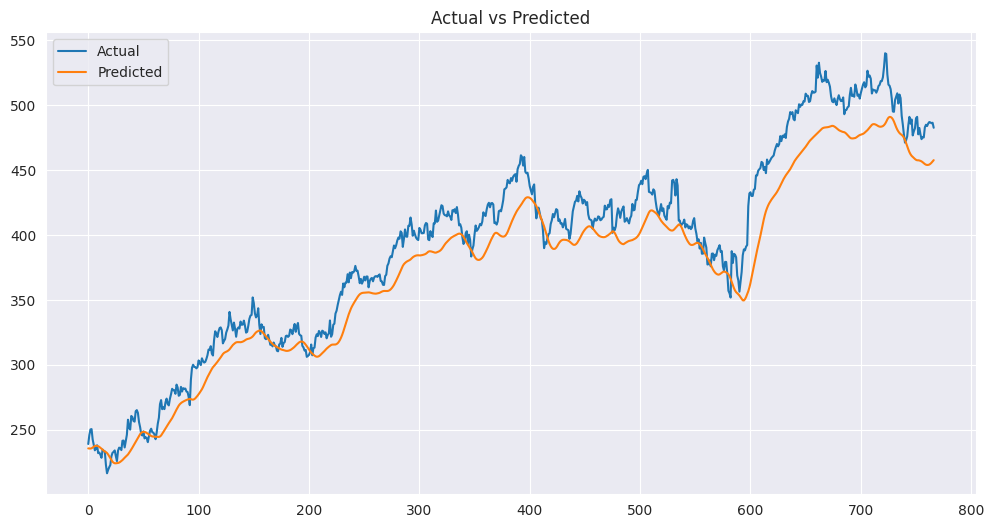

In [20]:
plt.figure(figsize=(12,6))

plt.plot(y_actual, label='Actual')
plt.plot(pred_actual, label='Predicted')

plt.legend()
plt.title('Actual vs Predicted')
plt.show()

In [21]:
print("Mean Squared Error:",mean_squared_error(y_actual,pred_actual))
print("Root Mean Squared Error:",root_mean_squared_error(y_actual,pred_actual))
print('r_2 statistic:%.2f' % r2_score(y_actual,pred_actual))

Mean Squared Error: 540.5048091228398
Root Mean Squared Error: 23.248759302871193
r_2 statistic:0.91


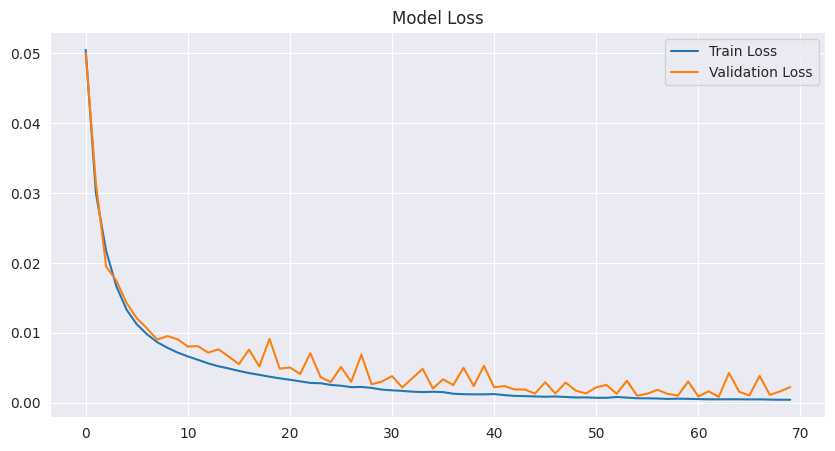

In [22]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title('Model Loss')
plt.show()